# 009 Embedding Challenger: Qwen3 Retrieval Evaluation

This notebook compares the existing BGE dev baseline with Qwen3 embedding results when those results exist. It does not run Qwen3 by default.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
BGE_OUT = ROOT / 'data' / 'eval' / 'nonself_retrieval_bge_dev'
QWEN_OUT = ROOT / 'data' / 'eval' / 'nonself_retrieval_qwen3_dev'

BGE_SUMMARY = BGE_OUT / 'retrieval_eval_summary_dev_bge_small_en_v15.json'
QWEN_DEV_SUMMARY = QWEN_OUT / 'retrieval_eval_summary_dev_qwen3_embedding_06b.json'
QWEN_SAMPLE_SUMMARY = QWEN_OUT / 'retrieval_eval_summary_sample_qwen3_embedding_06b.json'

assert BGE_SUMMARY.exists(), f'Missing BGE dev baseline: {BGE_SUMMARY}'

Qwen3 is larger than BGE. The commands below request GPU automatically and refuse CPU fallback by default.

In [2]:
RUN_QWEN_SAMPLE = True
RUN_QWEN_FULL_DEV = True
QWEN_DEVICE = 'auto'
REQUIRE_CUDA_FOR_QWEN = True

if RUN_QWEN_SAMPLE:
    qwen_sample_cmd = [
        sys.executable,
        str(ROOT / 'scripts' / 'evaluate_nonself_retrieval_bge.py'),
        '--model-key',
        'qwen3_embedding_06b',
        '--max-queries',
        '24',
        '--batch-size',
        '4',
        '--device',
        QWEN_DEVICE,
        '--no-oracle',
        '--summary',
    ]
    if REQUIRE_CUDA_FOR_QWEN:
        qwen_sample_cmd.append('--require-cuda')
    subprocess.run(qwen_sample_cmd, cwd=ROOT, check=True)

if RUN_QWEN_FULL_DEV:
    qwen_dev_cmd = [
        sys.executable,
        str(ROOT / 'scripts' / 'evaluate_nonself_retrieval_bge.py'),
        '--model-key',
        'qwen3_embedding_06b',
        '--batch-size',
        '4',
        '--device',
        QWEN_DEVICE,
        '--summary',
    ]
    if REQUIRE_CUDA_FOR_QWEN:
        qwen_dev_cmd.append('--require-cuda')
    subprocess.run(qwen_dev_cmd, cwd=ROOT, check=True)

## Available Runs

In [3]:
def read_summary(path: Path, model_label: str, run_label: str):
    summary = json.loads(path.read_text(encoding='utf-8'))
    rows = pd.DataFrame(summary['metrics'])
    rows.insert(0, 'model_label', model_label)
    rows.insert(1, 'run_label', run_label)
    return summary, rows

runs = []
bge_summary, bge_metrics = read_summary(BGE_SUMMARY, 'BGE small', 'dev')
runs.append((bge_summary, bge_metrics))

qwen_summary_path = None
qwen_run_label = ''
if QWEN_DEV_SUMMARY.exists():
    qwen_summary_path = QWEN_DEV_SUMMARY
    qwen_run_label = 'dev'
elif QWEN_SAMPLE_SUMMARY.exists():
    qwen_summary_path = QWEN_SAMPLE_SUMMARY
    qwen_run_label = 'sample'

if qwen_summary_path:
    qwen_summary, qwen_metrics = read_summary(
        qwen_summary_path,
        'Qwen3 embedding 0.6B',
        qwen_run_label,
    )
    runs.append((qwen_summary, qwen_metrics))
else:
    display(Markdown('Qwen3 retrieval outputs are not present yet.'))

all_metrics = pd.concat([metrics for _, metrics in runs], ignore_index=True)
display(all_metrics)

,model_label,run_label,profile,relevance_scope,queries,queries_without_positives,hit_at_1,hit_at_3,hit_at_5,hit_at_10,mrr,ndcg
0,BGE small,dev,flat_bge_small_en_v15,any_grade,387,0,0.6641,0.8915,0.9251,0.9612,0.7789,0.5050
1,BGE small,dev,flat_bge_small_en_v15,grade_2,283,104,0.3887,0.6714,0.7456,0.8163,0.5426,0.4109
2,BGE small,dev,rule_triage_filtered_bge_small_en_v15,any_grade,387,0,0.6796,0.8915,0.9302,0.9664,0.7896,0.5206
3,BGE small,dev,rule_triage_filtered_bge_small_en_v15,grade_2,283,104,0.3993,0.6784,0.7562,0.8233,0.5522,0.4210
4,BGE small,dev,oracle_domain_filtered_bge_small_en_v15,any_grade,387,0,0.6873,0.8966,0.9328,0.9742,0.7968,0.5283
5,BGE small,dev,oracle_domain_filtered_bge_small_en_v15,grade_2,283,104,0.4064,0.6820,0.7562,0.8339,0.5581,0.4265
6,Qwen3 embedding 0.6B,dev,flat_qwen3_embedding_06b,any_grade,387,0,0.6667,0.8630,0.9121,0.9664,0.7741,0.5274
7,Qwen3 embedding 0.6B,dev,flat_qwen3_embedding_06b,grade_2,283,104,0.4205,0.6572,0.7244,0.8375,0.5552,0.4267
8,Qwen3 embedding 0.6B,dev,rule_triage_filtered_qwen3_embedding_06b,any_grade,387,0,0.6822,0.8708,0.9302,0.9664,0.7847,0.5386
9,Qwen3 embedding 0.6B,dev,rule_triage_filtered_qwen3_embedding_06b,grade_2,283,104,0.4311,0.6643,0.7279,0.8410,0.5635,0.4327


## Metric Comparison

,model_label,run_label,profile,relevance_scope,queries,queries_without_positives,hit_at_1,hit_at_3,hit_at_5,hit_at_10,mrr,ndcg,profile_type,series
0,BGE small,dev,flat_bge_small_en_v15,any_grade,387,0,0.6641,0.8915,0.9251,0.9612,0.7789,0.5050,flat,BGE small / flat
1,BGE small,dev,flat_bge_small_en_v15,grade_2,283,104,0.3887,0.6714,0.7456,0.8163,0.5426,0.4109,flat,BGE small / flat
2,BGE small,dev,rule_triage_filtered_bge_small_en_v15,any_grade,387,0,0.6796,0.8915,0.9302,0.9664,0.7896,0.5206,rule_triage_filtered,BGE small / rule_triage_filtered
3,BGE small,dev,rule_triage_filtered_bge_small_en_v15,grade_2,283,104,0.3993,0.6784,0.7562,0.8233,0.5522,0.4210,rule_triage_filtered,BGE small / rule_triage_filtered
4,BGE small,dev,oracle_domain_filtered_bge_small_en_v15,any_grade,387,0,0.6873,0.8966,0.9328,0.9742,0.7968,0.5283,oracle_domain_filtered,BGE small / oracle_domain_filtered
5,BGE small,dev,oracle_domain_filtered_bge_small_en_v15,grade_2,283,104,0.4064,0.6820,0.7562,0.8339,0.5581,0.4265,oracle_domain_filtered,BGE small / oracle_domain_filtered
6,Qwen3 embedding 0.6B,dev,flat_qwen3_embedding_06b,any_grade,387,0,0.6667,0.8630,0.9121,0.9664,0.7741,0.5274,flat,Qwen3 embedding 0.6B / flat
7,Qwen3 embedding 0.6B,dev,flat_qwen3_embedding_06b,grade_2,283,104,0.4205,0.6572,0.7244,0.8375,0.5552,0.4267,flat,Qwen3 embedding 0.6B / flat
8,Qwen3 embedding 0.6B,dev,rule_triage_filtered_qwen3_embedding_06b,any_grade,387,0,0.6822,0.8708,0.9302,0.9664,0.7847,0.5386,rule_triage_filtered,Qwen3 embedding 0.6B / rule_triage_filtered
9,Qwen3 embedding 0.6B,dev,rule_triage_filtered_qwen3_embedding_06b,grade_2,283,104,0.4311,0.6643,0.7279,0.8410,0.5635,0.4327,rule_triage_filtered,Qwen3 embedding 0.6B / rule_triage_filtered


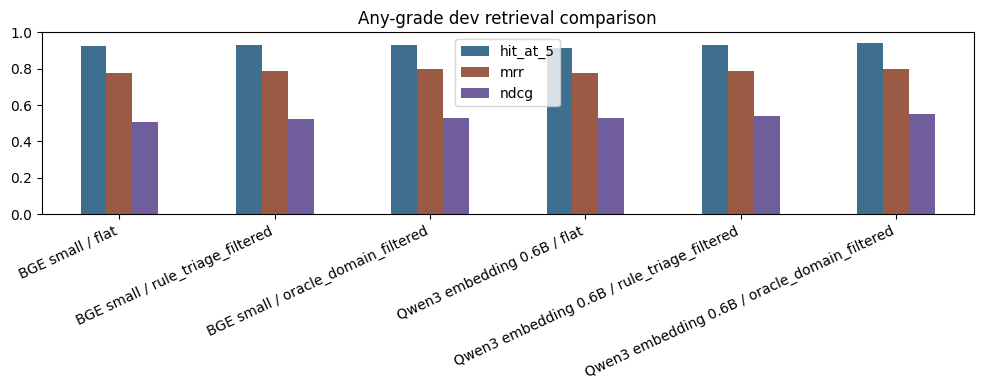

In [4]:
comparison = all_metrics.copy()
comparison['profile_type'] = comparison['profile'].str.replace(
    r'_(bge_small_en_v15|qwen3_embedding_06b)$',
    '',
    regex=True,
)
comparison['series'] = (
    comparison['model_label'] + ' / ' + comparison['profile_type']
)
display(comparison)

any_grade = comparison[comparison['relevance_scope'] == 'any_grade']
ax = any_grade.set_index('series')[['hit_at_5', 'mrr', 'ndcg']].plot.bar(
    figsize=(10, 4),
    color=['#3f6f8f', '#9a5a44', '#705d9b'],
)
ax.set_title('Any-grade dev retrieval comparison')
ax.set_xlabel('')
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Grade 2 Comparison

,model_label,run_label,profile,relevance_scope,queries,queries_without_positives,hit_at_1,hit_at_3,hit_at_5,hit_at_10,mrr,ndcg,profile_type,series
1,BGE small,dev,flat_bge_small_en_v15,grade_2,283,104,0.3887,0.6714,0.7456,0.8163,0.5426,0.4109,flat,BGE small / flat
3,BGE small,dev,rule_triage_filtered_bge_small_en_v15,grade_2,283,104,0.3993,0.6784,0.7562,0.8233,0.5522,0.4210,rule_triage_filtered,BGE small / rule_triage_filtered
5,BGE small,dev,oracle_domain_filtered_bge_small_en_v15,grade_2,283,104,0.4064,0.6820,0.7562,0.8339,0.5581,0.4265,oracle_domain_filtered,BGE small / oracle_domain_filtered
7,Qwen3 embedding 0.6B,dev,flat_qwen3_embedding_06b,grade_2,283,104,0.4205,0.6572,0.7244,0.8375,0.5552,0.4267,flat,Qwen3 embedding 0.6B / flat
9,Qwen3 embedding 0.6B,dev,rule_triage_filtered_qwen3_embedding_06b,grade_2,283,104,0.4311,0.6643,0.7279,0.8410,0.5635,0.4327,rule_triage_filtered,Qwen3 embedding 0.6B / rule_triage_filtered
11,Qwen3 embedding 0.6B,dev,oracle_domain_filtered_qwen3_embedding_06b,grade_2,283,104,0.4417,0.6678,0.7350,0.8481,0.5732,0.4412,oracle_domain_filtered,Qwen3 embedding 0.6B / oracle_domain_filtered


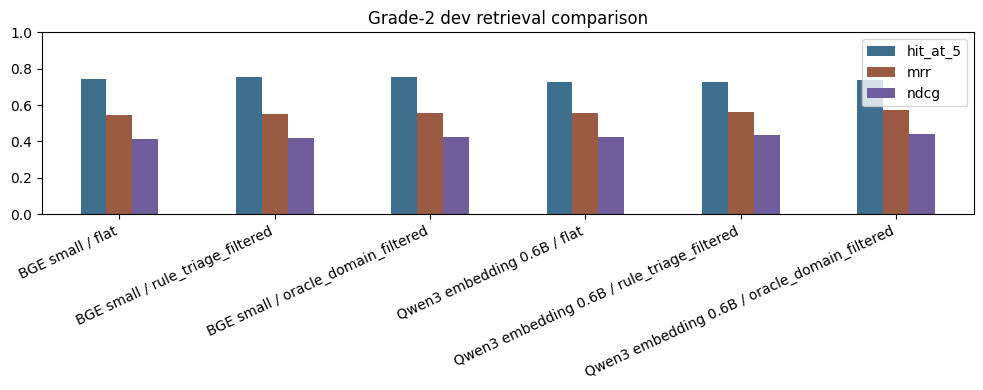

In [5]:
grade_2 = comparison[comparison['relevance_scope'] == 'grade_2']
display(grade_2)

ax = grade_2.set_index('series')[['hit_at_5', 'mrr', 'ndcg']].plot.bar(
    figsize=(10, 4),
    color=['#3f6f8f', '#9a5a44', '#705d9b'],
)
ax.set_title('Grade-2 dev retrieval comparison')
ax.set_xlabel('')
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## Run Summaries

In [6]:
summary_rows = []
for summary, _ in runs:
    summary_rows.append(
        {
            'model': summary['model']['key'],
            'scope': summary['scope'],
            'scored_queries': summary['input_counts']['scored_queries'],
            'model_load_seconds': summary['runtime_seconds']['model_load'],
            'embedding_seconds': summary['runtime_seconds']['embedding'],
            'total_seconds': summary['runtime_seconds']['total'],
            'batch_size': summary['settings']['batch_size'],
            'device': summary['model'].get('device', ''),
            'requested_device': summary['model'].get('requested_device', ''),
            'require_cuda': summary['model'].get('require_cuda', ''),
            'query_prompt_name': summary['model'].get('query_prompt_name', ''),
        }
    )
display(pd.DataFrame(summary_rows))

,model,scope,scored_queries,model_load_seconds,embedding_seconds,total_seconds,batch_size,device,requested_device,require_cuda,query_prompt_name
0,bge_small_en_v15,dev_only,387,8.018,39.072,49.592,16,cpu,,,
1,qwen3_embedding_06b,dev_only,387,8.176,16.995,27.498,4,cuda,auto,True,query


## Exit Criteria

- BGE dev remains the baseline.
- Qwen3 sample can be run first to confirm local runtime.
- Qwen3 full dev should be run before any holdout scoring.
- Holdout stays untouched until the dev comparison is reviewed.